<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/sarakazeminiahome6completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
file_path = '/content/drive/MyDrive/AIHC5020/gait/gait_session.txt'

In [6]:
try:
    with open(file_path, 'r') as f:
        file_content = f.read()
    print(file_content)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

﻿First Name;
Last Name;
Full Name;,  
Gender;Male
Age;
Reference;
Trial Time;10/11/2024 3:32:55 PM
Comment 1;
Comment 2;
Height;
Weight;
Left Leg Length;
Right Leg Length;
Partition Line;********************
Video File;vid0006_0005
Subject Number;123456

;;Step Ratio (cm. x min.);First Contact (sec.);Last Contact (sec.);Integ. Pressure (p x sec.);Foot Length (cm.);Foot Length %;Foot Width (cm.);Foot Area (cm. x cm.);Foot Angle (degrees);Toe In/Out Angle (degrees);Foot Toe X Location (cm.);Foot Toe Y Location (cm.);Foot Heel X Location (cm.);Foot Heel Y Location (cm.);Foot Center X Location (cm.);Foot Center Y Location (cm.);Step Length (cm.);Absolute Step Length (cm.);Stride Length (cm.);Stride Width (cm.);Step Time (sec.);Stride Time (sec.);Stride Velocity (cm./sec.);DOP (degrees);Gait Cycle Time (sec.);Stance Time (sec.);Stance %;Swing Time (sec.);Swing %;Single Support (sec.);Single Support %;Initial D. Support (sec.);Initial D. Support %;Terminal D. Support (sec.);Terminal D. Suppo

In [7]:
import pandas as pd
import io

def parse_gait_file(file_path):
    header_dict = {}
    data_lines = []
    in_header = True

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            stripped_line = line.strip()

            if ';Step Ratio' in stripped_line:
                # This is the start of the tabular data section
                in_header = False
                data_lines.append(stripped_line) # Add the header line for the CSV parser
                continue

            if in_header:
                if stripped_line:
                    parts = stripped_line.split(';', 1)
                    key = parts[0].strip()
                    value = parts[1].strip() if len(parts) > 1 else ''

                    # Clean specific header values if necessary
                    if key == 'Full Name':
                        value = value.rstrip(',') # Remove trailing comma

                    header_dict[key] = value if value != '' else None
            else:
                # Collect all lines after the header for DataFrame parsing
                data_lines.append(stripped_line)

    # Process tabular data using pandas
    # The first two columns are row identifiers
    # The first line collected in data_lines is the header for the DataFrame
    df = pd.read_csv(io.StringIO('\n'.join(data_lines)), sep=';', header=0, index_col=[0, 1])

    # Clean column names (remove leading/trailing spaces)
    df.columns = [col.strip() for col in df.columns]

    # Strip whitespace from index levels
    df.index = df.index.map(lambda x: tuple(el.strip() if isinstance(el, str) else el for el in x))

    return header_dict, df

# Example usage with the provided file_path
header_info, gait_data_df = parse_gait_file(file_path)

print("\n--- Header Information ---")
for key, value in header_info.items():
    print(f"{key}: {value}")

print("\n--- Gait Data DataFrame ---")
display(gait_data_df)



--- Header Information ---
﻿First Name: None
Last Name: None
Full Name: None
Gender: Male
Age: None
Reference: None
Trial Time: 10/11/2024 3:32:55 PM
Comment 1: None
Comment 2: None
Height: None
Weight: None
Left Leg Length: None
Right Leg Length: None
Partition Line: ********************
Video File: vid0006_0005
Subject Number: 123456

--- Gait Data DataFrame ---


Step Ratio (cm. x min.)  First Contact (sec.)  \
#Samples NaN                     14.000                18.000   
         Left                     8.000                10.000   
         Right                    6.000                 8.000   
Mean     NaN                      0.626                11.412   
         Left                     0.625                11.413   
         Right                    0.626                11.410   
Ratio    L/R                      0.999                 1.000   
ASI      NaN                      0.068                -0.026   
S.D.     NaN                      0.022                 4.006   
         Left                     0.028                 4.162   
         Right                    0.014                 4.086   
%CV      NaN                      3.574                35.100   
         Left                     4.468                36.464   
         Right                    2.294                35.812   

                Last Contact (sec.)  Integ. Pressure (p x sec.)  \
#Samples NaN                 18.000                      18.000   
         Left                10.000                      10.000   
         Right                8.000                       8.000   
Mean     NaN                 12.177                     252.750   
         Left                12.182                     249.257   
         Right               12.171                     257.115   
Ratio    L/R                  1.001                       0.969   
ASI      NaN                 -0.089                       3.103   
S.D.     NaN                  4.003                      21.681   
         Left                 4.161                      27.735   
         Right                4.081                      10.648   
%CV      NaN                 32.874                       8.578   
         Left                34.158                      11.127   
         Right               33.531                       4.141   

                Foot Length (cm.)  Foot Length %  Foot Width (cm.)  \
#Samples NaN               18.000         18.000            18.000   
         Left              10.000         10.000            10.000   
         Right              8.000          8.000             8.000   
Mean     NaN               31.767         96.349            11.746   
         Left              31.744         97.410            11.642   
         Right             31.797         95.021            11.877   
Ratio    L/R                0.998          1.025             0.980   
ASI      NaN                0.168         -2.483             2.004   
S.D.     NaN                0.665          2.346             0.591   
         Left               0.535          1.641             0.705   
         Right              0.839          2.506             0.418   
%CV      NaN                2.092          2.435             5.034   
         Left               1.685          1.685             6.057   
         Right              2.638          2.638             3.517   

                Foot Area (cm. x cm.)  Foot Angle (degrees)  \
#Samples NaN                   18.000                18.000   
         Left                  10.000                10.000   
         Right                  8.000                 8.000   
Mean     NaN                  292.985               -13.349   
         Left                 290.064               -83.197   
         Right                296.636                73.962   
Ratio    L/R                    0.978                -1.125   
ASI      NaN                    2.240                   NaN   
S.D.     NaN                   14.372               122.228   
         Left                  15.017                94.344   
         Right                 13.575                95.689   
%CV      NaN                    4.905              -915.649   
         Left                   5.177              -113.398   
         Right                  4.576               129.376   

                Toe In/Out Angle (deg

In [8]:
#problem2
import matplotlib.pyplot as plt
import numpy as np

def plot_gait_comparison(gait_df, parameters_to_plot, metric):
    """
    Visualizes a comparison between left and right-side gait metrics using a grouped bar chart.

    Args:
        gait_df (pd.DataFrame): The Pandas DataFrame returned by parse_gait_file.
        parameters_to_plot (list): A list of column names (gait parameters) to plot.
        metric (str): The statistic to plot from the index (e.g., 'Mean', 'S.D.', 'ASI').
    """
    # Filter the DataFrame for the specified metric
    try:
        metric_data = gait_df.loc[metric]
    except KeyError:
        print(f"Error: Metric '{metric}' not found in DataFrame index.")
        return

    # Extract 'Left' and 'Right' group data for the selected parameters
    left_values = []
    right_values = []

    for param in parameters_to_plot:
        try:
            left_values.append(metric_data.loc['Left', param])
            right_values.append(metric_data.loc['Right', param])
        except KeyError:
            print(f"Warning: Parameter '{param}' for 'Left' or 'Right' not found for metric '{metric}'. Skipping.")
            left_values.append(np.nan) # Append NaN for missing data
            right_values.append(np.nan) # Append NaN for missing data

    # Remove NaNs if any parameters were skipped
    cleaned_parameters = []
    cleaned_left_values = []
    cleaned_right_values = []

    for i, param in enumerate(parameters_to_plot):
        if not (pd.isna(left_values[i]) or pd.isna(right_values[i])):
            cleaned_parameters.append(param)
            cleaned_left_values.append(left_values[i])
            cleaned_right_values.append(right_values[i])

    if not cleaned_parameters:
        print("No valid parameters found to plot after filtering. Aborting plot.")
        return

    # Set up plot parameters
    x = np.arange(len(cleaned_parameters))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 7))
    rects1 = ax.bar(x - width/2, cleaned_left_values, width, label='Left', color='skyblue')
    rects2 = ax.bar(x + width/2, cleaned_right_values, width, label='Right', color='lightcoral')

    # Add text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(f'{metric} Value')
    ax.set_xlabel('Gait Parameter')
    ax.set_title(f'Gait Comparison for {metric} Values (Left vs. Right)')
    ax.set_xticks(x)
    ax.set_xticklabels(cleaned_parameters, rotation=45, ha='right') # Rotate for readability
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    plt.show()


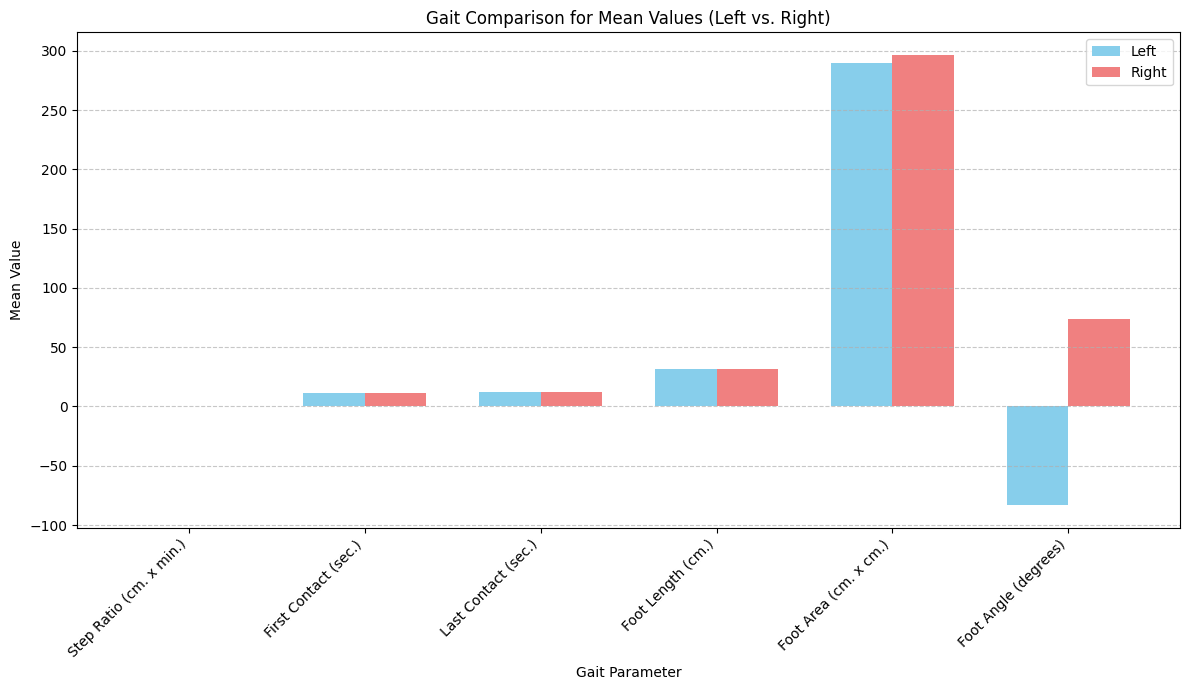

In [9]:
# Define the parameters to plot and the metric
parameters_to_plot = [
    'Step Ratio (cm. x min.)',
    'First Contact (sec.)',
    'Last Contact (sec.)',
    'Foot Length (cm.)',
    'Foot Area (cm. x cm.)',
    'Foot Angle (degrees)'
]
metric_to_plot = 'Mean'

# Call the function
plot_gait_comparison(gait_data_df, parameters_to_plot, metric_to_plot)

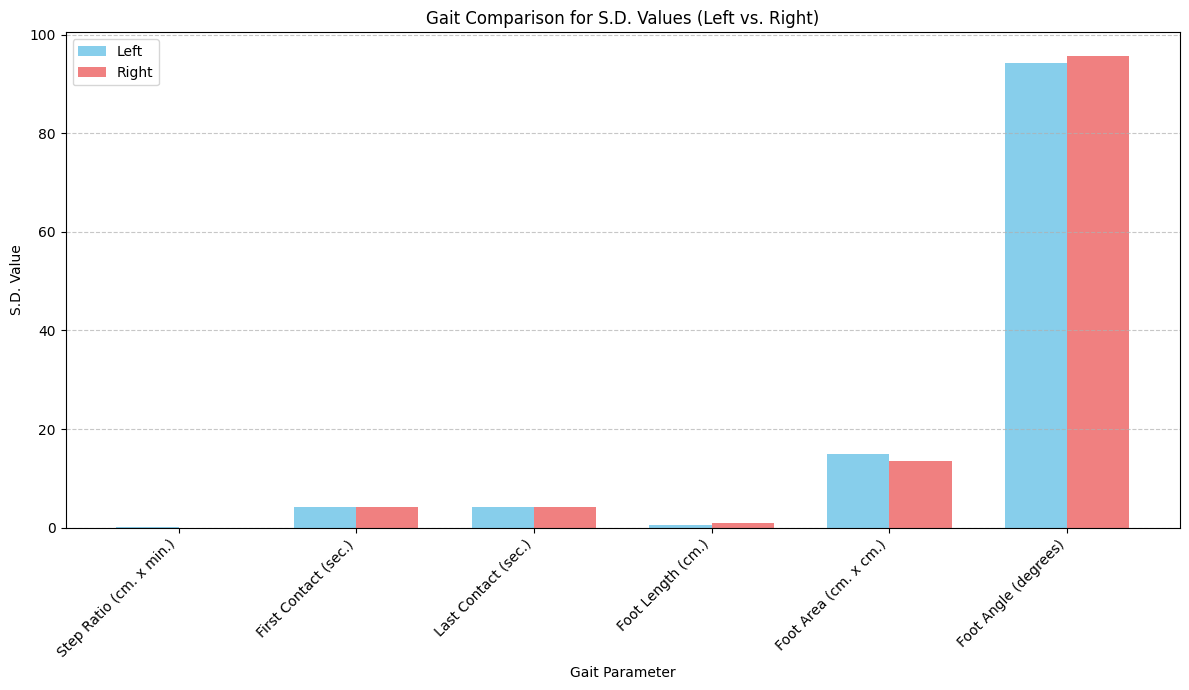

In [10]:
# Let's try with a different metric, for example, 'S.D.' (Standard Deviation)
metric_to_plot_sd = 'S.D.'

# You can use the same parameters_to_plot list
plot_gait_comparison(gait_data_df, parameters_to_plot, metric_to_plot_sd)

In [11]:
# And with 'ASI' (Asymmetry Index)
metric_to_plot_asi = 'ASI'

# Note: ASI values might only exist for a single entry per parameter, not 'Left'/'Right' groups.
# The function handles this by skipping if 'Left' or 'Right' data is not found.
plot_gait_comparison(gait_data_df, parameters_to_plot, metric_to_plot_asi)


No valid parameters found to plot after filtering. Aborting plot.


problem3

In [12]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

In [13]:
def parse_single_report(file_path):
    """
    Parses a single XML report file and extracts relevant information.

    Args:
        file_path (str): The path to the XML file.

    Returns:
        dict: A dictionary containing extracted information (uId, Comparison, Indication,
              Findings, Impression, Image_IDs).
    """
    tree = ET.parse(file_path)
    root = tree.getroot()

    report_data = {
        'uId': None,
        'Comparison': None,
        'Indication': None,
        'Findings': None,
        'Impression': None,
        'Image_IDs': []
    }

    # Extract uId
    uId_element = root.find('uId')
    if uId_element is not None:
        report_data['uId'] = uId_element.get('id')

    # Extract Abstract Sections
    abstract_element = root.find('Abstract')
    if abstract_element is not None:
        for abstract_text_element in abstract_element.findall('AbstractText'):
            label = abstract_text_element.get('Label')
            text = abstract_text_element.text
            if label == 'COMPARISON':
                report_data['Comparison'] = text.strip() if text else None
            elif label == 'INDICATION':
                report_data['Indication'] = text.strip() if text else None
            elif label == 'FINDINGS':
                report_data['Findings'] = text.strip() if text else None
            elif label == 'IMPRESSION':
                report_data['Impression'] = text.strip() if text else None

    # Extract Image IDs
    for parent_image_element in root.findall('parentImage'):
        image_id = parent_image_element.get('id')
        if image_id:
            report_data['Image_IDs'].append(image_id)

    return report_data

In [14]:
def process_xml_directory(directory_path):
    """
    Processes all XML reports in a given directory and aggregates their information
    into a Pandas DataFrame.

    Args:
        directory_path (str): The path to the folder containing the .xml files.

    Returns:
        pd.DataFrame: A DataFrame with extracted information from all XML files.
    """
    all_reports_data = []

    for filename in os.listdir(directory_path):
        if filename.endswith('.xml'):
            file_path = os.path.join(directory_path, filename)
            report_data = parse_single_report(file_path)
            all_reports_data.append(report_data)

    df = pd.DataFrame(all_reports_data)
    return df

In [15]:
directory_path = '/content/drive/MyDrive/AIHC5020/emr/rad_reports/'

# Process the directory
reports_df = process_xml_directory(directory_path)

# Display the resulting DataFrame
display(reports_df.head())

,uId,Comparison,Indication,Findings,Impression,Image_IDs
0,CXR3123,None,None,None,None,"[CXR3123_IM-1468-1001, CXR3123_IM-1468-2001]"
1,CXR3169,None,None,None,None,"[CXR3169_IM-1492-1001, CXR3169_IM-1492-2001]"
2,CXR3140,None,None,None,None,"[CXR3140_IM-1477-1001, CXR3140_IM-1477-2001]"
3,CXR3211,None,None,None,None,"[CXR3211_IM-1517-1001-0001, CXR3211_IM-1517-10..."
4,CXR3240,None,None,None,None,"[CXR3240_IM-1534-1001, CXR3240_IM-1534-2001]"


Problem 4: Generating LLM Prompt

In [16]:
import pandas as pd


def generate_llm_prompt(report_row):
    """
    Generate an LLM prompt from one chest X-ray report row.

    Parameters
    ----------
    report_row : pandas.Series
        A row containing Comparison, Indication, Findings, and Impression.

    Returns
    -------
    str
        A complete prompt requesting diagnoses in JSON format.
    """

    # Safely retrieve each field and replace missing values with an empty string
    def get_text(column_name):
        value = report_row.get(column_name, "")
        return "" if pd.isna(value) else str(value).strip()

    comparison = get_text("Comparison")
    indication = get_text("Indication")
    findings = get_text("Findings")
    impression = get_text("Impression")

    cardio_diagnoses = [
        "cardiomegaly",
        "vascular_congestion",
        "atherosclerosis",
        "normal",
        "other",
        "not_evaluated"
    ]

    pulmonary_diagnoses = [
        "atelectasis",
        "consolidation",
        "effusion",
        "nodule",
        "infectious",
        "normal",
        "other",
        "not_evaluated"
    ]

    prompt = f"""You are an expert medical coding assistant. Your task is to analyze the following sections of a chest X-ray radiology report and determine the single primary cardiological diagnosis and the single primary pulmonary diagnosis.

--- REPORT TEXT ---
COMPARISON: {comparison}
INDICATION: {indication}
FINDINGS: {findings}
IMPRESSION: {impression}
--- END REPORT TEXT ---

Please adhere to the following rules:
1.  Choose exactly one diagnosis for the heart/cardiovascular system from this list: {cardio_diagnoses}.
2.  Choose exactly one diagnosis for the lungs/pulmonary system from this list: {pulmonary_diagnoses}.
3.  Use 'normal' if the organ system is described as unremarkable or without acute findings.
4.  Use 'other' only if a clear diagnosis is stated that is not on the provided list.
5.  Use 'not_evaluated' if the report does not contain enough information to make a judgment about that organ system.

Your response MUST be a single, valid JSON object and nothing else. Do not include any explanations or introductory text.

Format your response as follows:
{{"cardio_diag": "your_cardio_diagnosis", "pulmonary_diag": "your_pulmonary_diagnosis"}}"""

    return prompt


Problem 5

In [17]:
from google.colab import userdata

hf_token = userdata.get('hf_token')
print(f"HF Token loaded successfully: {hf_token is not None}")
# You can verify the token, but avoid printing the token itself for security reasons.

HF Token loaded successfully: True


In [18]:
import requests

API_URL = "https://router.huggingface.co/v1/chat/completions"

def query(payload, hf_token):
    headers = {
        "Authorization": f"Bearer {hf_token}"
    }
    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()

In [19]:
import json
import re # Import regex for JSON extraction

def get_llm_diagnoses(prompt: str, api_token: str):
    try:
        # Construct the payload
        payload = {
            "messages": [
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "model": "openai/gpt-oss-120b"
        }

        # Call the query function
        response_json = query(payload, api_token)

        # Check if the API call was successful and response has content
        if not response_json or 'choices' not in response_json or not response_json['choices']:
            print("API response was empty or malformed.")
            return None

        # Extract the model's text response
        model_response_content = response_json['choices'][0]['message']['content']

        # Extract the clean JSON string from the model's response
        # Reliably find and extract only the JSON string (from the first { to the last })Blake
        # Using regex to find the first '{' and last '}'
        json_match = re.search(r'\{.*\}', model_response_content, re.DOTALL)
        if not json_match:
            print("No JSON object found in model's response.")
            return None

        clean_json_string = json_match.group(0)

        # Parse the final result
        final_result = json.loads(clean_json_string)
        return final_result

    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from model response: {e}")
        print(f"Problematic JSON string: {clean_json_string}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


In [20]:
sample_report_row = reports_df.iloc[0]
llm_prompt = generate_llm_prompt(sample_report_row)

print("--- Generated LLM Prompt ---")
print(llm_prompt)

--- Generated LLM Prompt ---
You are an expert medical coding assistant. Your task is to analyze the following sections of a chest X-ray radiology report and determine the single primary cardiological diagnosis and the single primary pulmonary diagnosis.

--- REPORT TEXT ---
COMPARISON: 
INDICATION: 
FINDINGS: 
IMPRESSION: 
--- END REPORT TEXT ---

Please adhere to the following rules:
1.  Choose exactly one diagnosis for the heart/cardiovascular system from this list: ['cardiomegaly', 'vascular_congestion', 'atherosclerosis', 'normal', 'other', 'not_evaluated'].
2.  Choose exactly one diagnosis for the lungs/pulmonary system from this list: ['atelectasis', 'consolidation', 'effusion', 'nodule', 'infectious', 'normal', 'other', 'not_evaluated'].
3.  Use 'normal' if the organ system is described as unremarkable or without acute findings.
4.  Use 'other' only if a clear diagnosis is stated that is not on the provided list.
5.  Use 'not_evaluated' if the report does not contain enough inf

In [21]:
print("\n--- LLM Diagnoses ---")
llm_diagnoses = get_llm_diagnoses(llm_prompt, hf_token)

if llm_diagnoses:
    print(json.dumps(llm_diagnoses, indent=2))
else:
    print("Failed to retrieve LLM diagnoses.")


--- LLM Diagnoses ---
{
  "cardio_diag": "not_evaluated",
  "pulmonary_diag": "not_evaluated"
}


problem 6

## Problem 6: Parsing FHIR R4 JSON Patient Records

This problem requires parsing deeply nested FHIR R4 JSON patient records to extract key demographic information and a summary of patient encounters. The goal is to compile all extracted data into a single, clean Pandas DataFrame for analysis.

**Steps:**
1.  Define the path to the directory containing the FHIR R4 JSON files.
2.  Develop a function to parse a single FHIR JSON file, extracting relevant demographic details and encounter summaries.
3.  Develop a function to iterate through all JSON files in the specified directory, applying the parsing function and aggregating the results into a Pandas DataFrame.
4.  Display the head of the resulting DataFrame to verify the extracted data.

Now, let's process the FHIR directory and display the head of the resulting DataFrame.

In [25]:
import os

does_path_exist = os.path.exists(fhir_directory_path)
print(f"Does the FHIR directory exist at '{fhir_directory_path}'? {does_path_exist}")

if not does_path_exist:
    print("Please ensure your Google Drive is mounted and the path to the FHIR files is correct.")
    print("You might need to run `from google.colab import drive; drive.mount('/content/drive')` if your drive is not mounted.")


Does the FHIR directory exist at '/content/drive/MyDrive/AIHC5020/emr/fihr'? False
Please ensure your Google Drive is mounted and the path to the FHIR files is correct.
You might need to run `from google.colab import drive; drive.mount('/content/drive')` if your drive is not mounted.


In [27]:
import json
import pandas as pd
import os
from datetime import datetime
import numpy as np

def parse_single_patient_record(json_data):
    """
    Parses a single FHIR R4 JSON data object to extract patient demographics,
    encounter summaries, and computed age information.

    Args:
        json_data (dict): The loaded JSON data from a FHIR R4 patient record file.

    Returns:
        dict: A dictionary containing extracted and computed patient information.
    """
    patient_info = {
        'given_name': None,
        'family_name': None,
        'mrn': None,
        'dob': None,
        'gender': None,
        'birth_sex': None,
        'race': None,
        'ethnicity': None,
        'home_city': None,
        'home_state': None,
        'dod': None,
        'age_at_death': np.nan,
        'current_age': np.nan,
        'encounter_reasons': []
    }

    patient_resource = None
    encounter_resources = []

    # Navigate the Bundle to find Patient and Encounter resources
    if json_data.get('resourceType') == 'Bundle':
        for entry in json_data.get('entry', []):
            resource = entry.get('resource', {})
            if resource.get('resourceType') == 'Patient':
                patient_resource = resource
            elif resource.get('resourceType') == 'Encounter':
                encounter_resources.append(resource)
    elif json_data.get('resourceType') == 'Patient': # Handle case where JSON is just a Patient resource
        patient_resource = json_data
    elif json_data.get('resourceType') == 'Encounter': # Handle case where JSON is just an Encounter resource
        encounter_resources.append(json_data)

    if not patient_resource and not encounter_resources:
        return None # No relevant resources found

    # Extract information from Patient Resource
    if patient_resource:
        # Name
        name_list = patient_resource.get('name', [])
        if name_list:
            patient_info['given_name'] = name_list[0].get('given', [None])[0]
            patient_info['family_name'] = name_list[0].get('family')

        # MRN
        identifier_list = patient_resource.get('identifier', [])
        for ident in identifier_list:
            if ident.get('type', {}).get('text') == 'Medical Record Number':
                patient_info['mrn'] = ident.get('value')
                break

        # DOB & Gender
        patient_info['dob'] = patient_resource.get('birthDate')
        patient_info['gender'] = patient_resource.get('gender')

        # Birth Sex, Race, Ethnicity from Extensions
        for ext in patient_resource.get('extension', []):
            url = ext.get('url')
            if 'us-core-birthsex' in url:
                patient_info['birth_sex'] = ext.get('valueCode')
            elif 'us-core-race' in url:
                patient_info['race'] = ext.get('valueCoding', {}).get('display')
            elif 'us-core-ethnicity' in url:
                patient_info['ethnicity'] = ext.get('valueCoding', {}).get('display')

        # Home Address
        address_list = patient_resource.get('address', [])
        for addr in address_list:
            if addr.get('use') == 'home':
                patient_info['home_city'] = addr.get('city')
                patient_info['home_state'] = addr.get('state')
                break

        # Date of Death
        patient_info['dod'] = patient_resource.get('deceasedDateTime')

        # Computed Fields: Age
        if patient_info['dob']:
            dob_dt = datetime.strptime(patient_info['dob'], '%Y-%m-%d')
            if patient_info['dod']:
                dod_dt = datetime.fromisoformat(patient_info['dod'].replace('Z', '+00:00')) # Handle 'Z' for UTC
                age_delta = dod_dt - dob_dt
                patient_info['age_at_death'] = round(age_delta.days / 365.25, 2)
            else:
                # Calculate current age if not deceased
                now_dt = datetime.now()
                age_delta = now_dt - dob_dt
                patient_info['current_age'] = round(age_delta.days / 365.25, 2)

    # Extract Encounter Reasons
    for encounter in encounter_resources:
        reason_codes = encounter.get('reasonCode', [])
        for rc in reason_codes:
            coding_list = rc.get('coding', [])
            if coding_list:
                display_text = coding_list[0].get('display')
                if display_text:
                    patient_info['encounter_reasons'].append(display_text)

    # If no patient resource was found, but encounters exist, we might still want to return something
    # or infer patient_id from encounter patient reference, but the problem focuses on Patient resource
    # For this problem, if no patient_resource is found, we can't extract most info, so return None
    if not patient_resource:
        return None

    return patient_info


In [28]:
def process_fhir_directory(directory_path):
    """
    Processes all FHIR JSON files in a given directory, extracts patient information,
    and compiles it into a Pandas DataFrame.

    Args:
        directory_path (str): The path to the folder containing the FHIR JSON files.

    Returns:
        pd.DataFrame: A DataFrame with extracted information from all FHIR files.
    """
    all_patient_data = []

    if not os.path.exists(directory_path):
        print(f"Error: Directory not found at '{directory_path}'")
        return pd.DataFrame() # Return empty DataFrame on error

    for filename in os.listdir(directory_path):
        if filename.endswith('.json'):
            file_path = os.path.join(directory_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    json_data = json.load(f)

                patient_record = parse_single_patient_record(json_data)
                if patient_record:
                    all_patient_data.append(patient_record)
            except (json.JSONDecodeError, FileNotFoundError) as e:
                print(f"Error processing {file_path}: {e}")
            except Exception as e:
                print(f"An unexpected error occurred with {file_path}: {e}")

    df = pd.DataFrame(all_patient_data)

    # Ensure encounter_reasons is a list, not a single string representation of a list
    if 'encounter_reasons' in df.columns:
        df['encounter_reasons'] = df['encounter_reasons'].apply(lambda x: x if isinstance(x, list) else [])

    return df


Now, let's process the FHIR directory with the updated functions and display the head of the resulting DataFrame.

In [29]:
# Process the FHIR directory using the updated function
fhir_df = process_fhir_directory(fhir_directory_path)

# Display the resulting DataFrame
display(fhir_df.head())

print(f"Total patient records processed: {len(fhir_df)}")

Error: Directory not found at '/content/drive/MyDrive/AIHC5020/emr/fihr'


""


Total patient records processed: 0


In [26]:
{
    "resourceType": "Bundle",
    "entry": [
        {
            "resource": {
                "resourceType": "Patient",
                "identifier": [
                    {
                        "type": { "text": "Medical Record Number" },
                        "value": "MRN12345"
                    }
                ],
                "name": [ { "family": "Smith", "given": ["John", "B."] } ],
                "gender": "male",
                "birthDate": "1965-08-15",
                "deceasedDateTime": "2022-11-20T10:00:00Z",
                "extension": [
                    {
                        "url": "http://hl7.org/fhir/us/core/StructureDefinition/us-core-race",
                        "valueCoding": { "display": "White" }
                    },
                    {
                        "url": "http://hl7.org/fhir/us/core/StructureDefinition/us-core-birthsex",
                        "valueCode": "M"
                    }
                ],
                "address": [ { "use": "home", "city": "Boston", "state": "MA" } ]
            }
        },
        {
            "resource": {
                "resourceType": "Encounter",
                "reasonCode": [
                    {
                        "coding": [
                            { "display": "Routine health maintenance" }
                        ]
                    }
                ]
            }
        },
        {
            "resource": {
                "resourceType": "Encounter",
                "reasonCode": [
                    { "coding": [ { "display": "Chest pain" } ] }
                ]
            }
        }
    ]
}

{'resourceType': 'Bundle',
 'entry': [{'resource': {'resourceType': 'Patient',
    'identifier': [{'type': {'text': 'Medical Record Number'},
      'value': 'MRN12345'}],
    'name': [{'family': 'Smith', 'given': ['John', 'B.']}],
    'gender': 'male',
    'birthDate': '1965-08-15',
    'deceasedDateTime': '2022-11-20T10:00:00Z',
    'extension': [{'url': 'http://hl7.org/fhir/us/core/StructureDefinition/us-core-race',
      'valueCoding': {'display': 'White'}},
     {'url': 'http://hl7.org/fhir/us/core/StructureDefinition/us-core-birthsex',
      'valueCode': 'M'}],
    'address': [{'use': 'home', 'city': 'Boston', 'state': 'MA'}]}},
  {'resource': {'resourceType': 'Encounter',
    'reasonCode': [{'coding': [{'display': 'Routine health maintenance'}]}]}},
  {'resource': {'resourceType': 'Encounter',
    'reasonCode': [{'coding': [{'display': 'Chest pain'}]}]}}]}